In [1]:
import numpy as np
np.set_printoptions(threshold=10000, suppress=True)

import pandas as pd
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*threadpoolctl.*")
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [2]:
# Import utils.py
import importlib
import utils
importlib.reload(utils)



<module 'utils' from '/home/ilicia/data/tpapi/utils.py'>

### 1. Chargement des données et préparation

Dans cette section, nous importons le jeu de données, séparons les variables explicatives et la cible, et analysons les propriétés du dataset (taille, répartition des classes, etc.).

In [144]:
# Chargement des données
data = pd.read_csv("credit_scoring.csv", sep=";")

# Affichage des premières lignes
data.head()


,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price,Status
0,9.0,1.0,60.0,30.0,0.0,1.0,1.0,73.0,129.0,0.0,0.0,800.0,846.0,1
1,17.0,1.0,60.0,58.0,1.0,1.0,0.0,48.0,131.0,0.0,0.0,1000.0,1658.0,1
2,10.0,0.0,36.0,46.0,0.0,2.0,1.0,90.0,200.0,3000.0,0.0,2000.0,2985.0,0
3,0.0,1.0,60.0,24.0,1.0,1.0,0.0,63.0,182.0,2500.0,0.0,900.0,1325.0,1
4,0.0,1.0,36.0,26.0,1.0,1.0,0.0,46.0,107.0,0.0,0.0,310.0,910.0,1


In [145]:
# Variables explicatives
X = data.drop("Status", axis=1).values

# Variable cible
y = data["Status"].values

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)


Forme de X : (4375, 13)
Forme de y : (4375,)


Taille totale du dataset : (4375, 14)

Répartition des classes (%):
Status
1    72.205714
0    27.794286
Name: proportion, dtype: float64


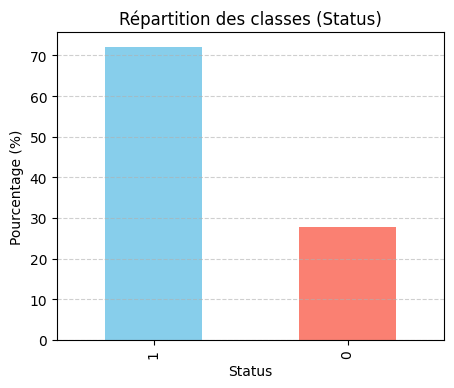

In [146]:
# Taille du dataset
print("Taille totale du dataset :", data.shape)

# Pourcentage des classes
pourcentages = data["Status"].value_counts(normalize=True) * 100
print("\nRépartition des classes (%):")
print(pourcentages)

# Graphique
plt.figure(figsize=(5,4))
pourcentages.plot(kind='bar', color=['skyblue','salmon'])
plt.title("Répartition des classes (Status)")
plt.ylabel("Pourcentage (%)")
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1, stratify=y)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape) 


X_train : (2187, 13)
X_test  : (2188, 13)


In [148]:
#  Taille de l’échantillon
print("Taille de l’échantillon (shape) :", data.shape)
print(f"→ Nombre de lignes : {data.shape[0]}")
print(f"→ Nombre de colonnes : {data.shape[1]}")

Taille de l’échantillon (shape) : (4375, 14)
→ Nombre de lignes : 4375
→ Nombre de colonnes : 14


In [149]:
# Répartition de la variable cible 'Status'
print("\nRépartition des classes dans 'Status' :")
print(data['Status'].value_counts())


Répartition des classes dans 'Status' :
Status
1    3159
0    1216
Name: count, dtype: int64


In [150]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "CART": DecisionTreeClassifier(random_state=1),
    "kNN": KNeighborsClassifier(n_neighbors=5, n_jobs=1),
    "MLP": MLPClassifier(hidden_layer_sizes=(40,20), max_iter=5000, random_state=1)
}


#### Choix du critère d’évaluation : Précision

Dans le contexte du crédit scoring, l’objectif est d’être sûr que les clients à qui l’on accorde un crédit sont vraiment de « bons » clients, c’est-à-dire qu’ils rembourseront leur crédit.  
Il est donc plus important de maximiser la **précision** sur la classe des bons clients (Status = 1), afin de limiter le risque d’accorder un crédit à un mauvais payeur par erreur.  
C’est pourquoi, dans la suite du TP, le critère principal retenu pour comparer les modèles sera la **précision**.


🔷 Entraînement du modèle : CART


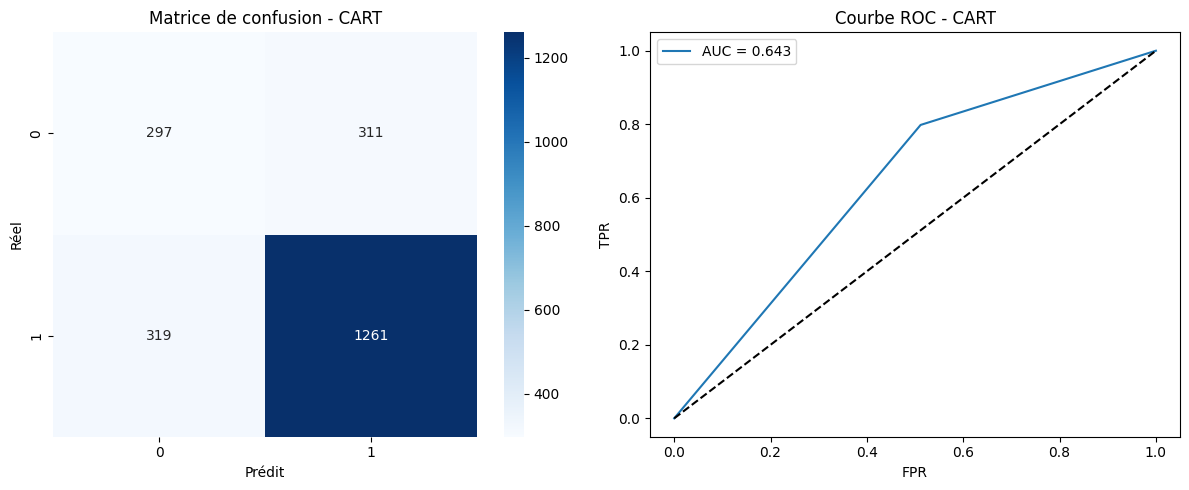


=== CART ===
Accuracy   : 0.712
Rappel     : 0.798
Précision  : 0.802
AUC        : 0.643
Critère choisi : Précision
Score final = (0.712 + 0.802) / 2 = 0.757


🔷 Entraînement du modèle : kNN


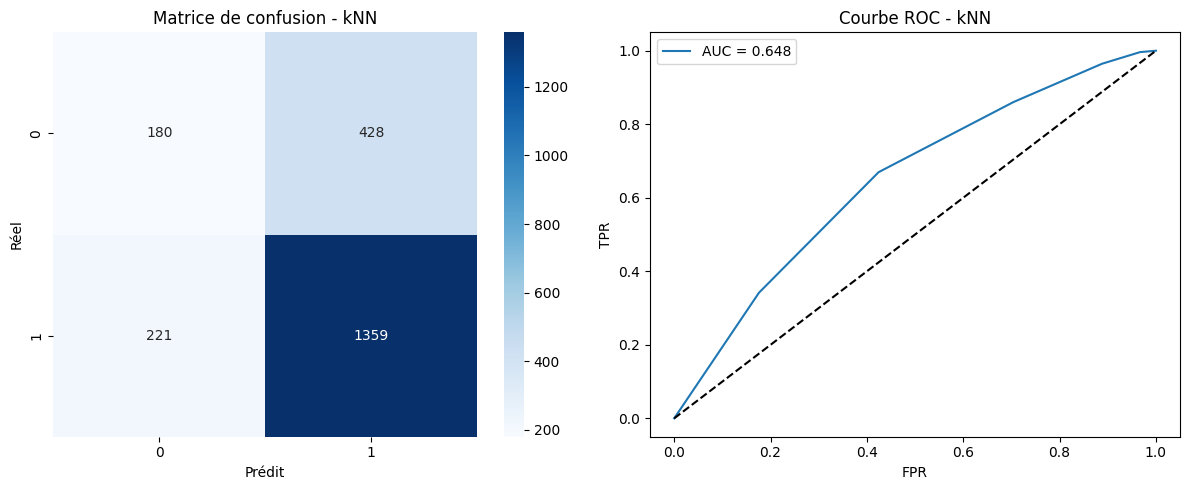


=== kNN ===
Accuracy   : 0.703
Rappel     : 0.860
Précision  : 0.760
AUC        : 0.648
Critère choisi : Précision
Score final = (0.703 + 0.760) / 2 = 0.732


🔷 Entraînement du modèle : MLP


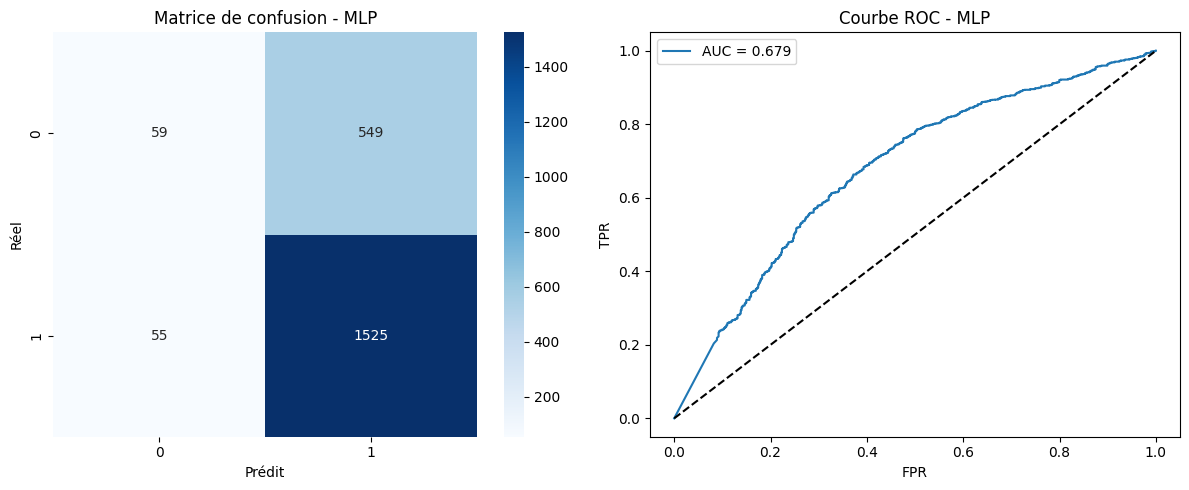


=== MLP ===
Accuracy   : 0.724
Rappel     : 0.965
Précision  : 0.735
AUC        : 0.679
Critère choisi : Précision
Score final = (0.724 + 0.735) / 2 = 0.730


===== Résultats finaux =====
CART       → Score final : 0.757
kNN        → Score final : 0.732
MLP        → Score final : 0.730

 Meilleur modèle : CART (score = 0.757)


In [151]:
best_model_raw = utils.run_classifiers_train_test(
    models, X_train, y_train, X_test, y_test, metric="precision"
)


### 3. Normalisation des variables continues

Dans cette section, nous appliquons une normalisation (StandardScaler) sur les variables continues, puis nous réévaluons les modèles sur les données normalisées afin de comparer les performances avec et sans normalisation.

In [152]:
X_train_norm, X_test_norm, scaler = utils.normalize_data(X_train, X_test)

print("X_train_norm shape :", X_train_norm.shape)
print("X_test_norm  shape :", X_test_norm.shape)


X_train_norm shape : (2187, 13)
X_test_norm  shape : (2188, 13)



🔷 Entraînement du modèle : CART


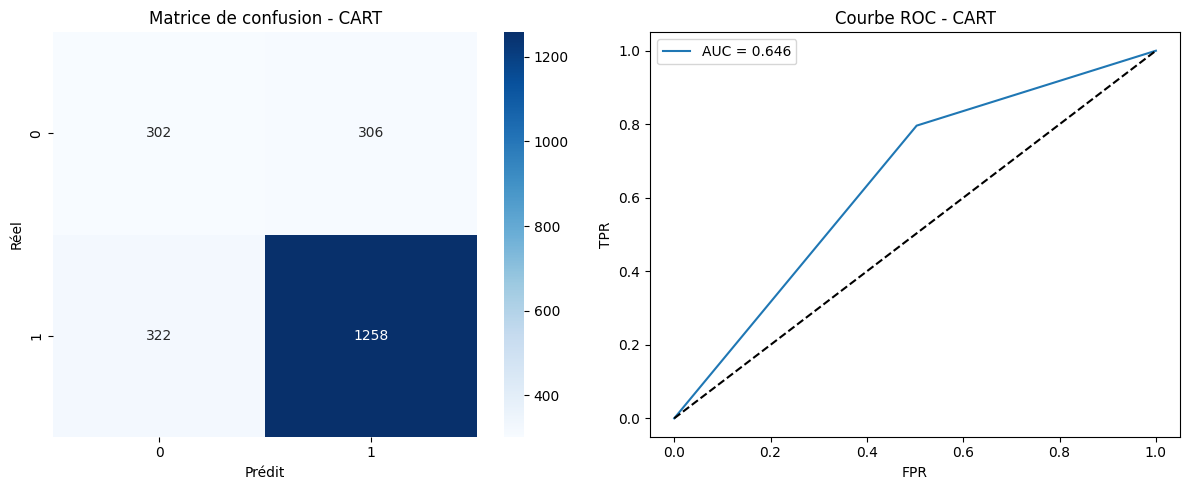


=== CART ===
Accuracy   : 0.713
Rappel     : 0.796
Précision  : 0.804
AUC        : 0.646
Critère choisi : Précision
Score final = (0.713 + 0.804) / 2 = 0.759


🔷 Entraînement du modèle : kNN


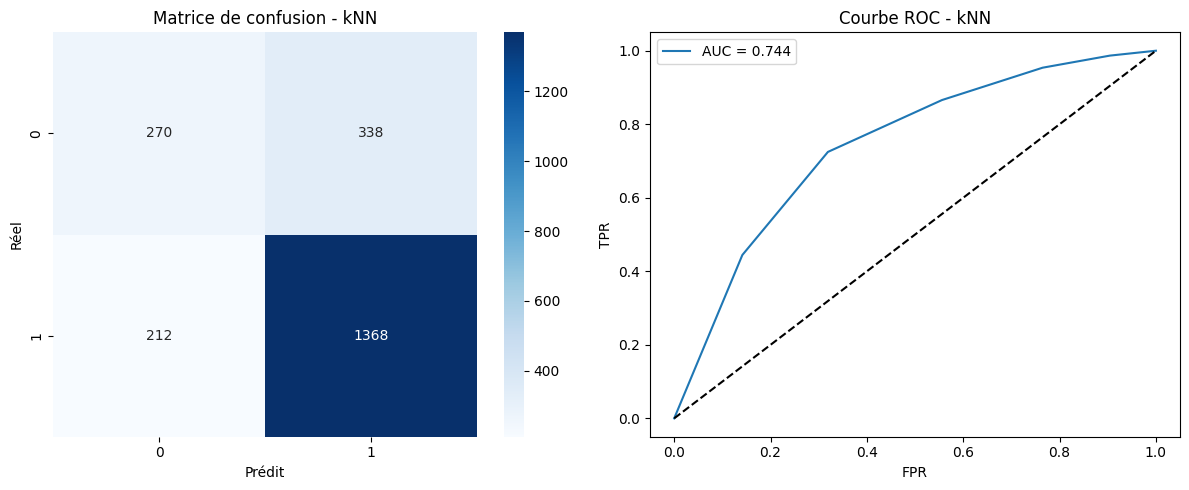


=== kNN ===
Accuracy   : 0.749
Rappel     : 0.866
Précision  : 0.802
AUC        : 0.744
Critère choisi : Précision
Score final = (0.749 + 0.802) / 2 = 0.775


🔷 Entraînement du modèle : MLP


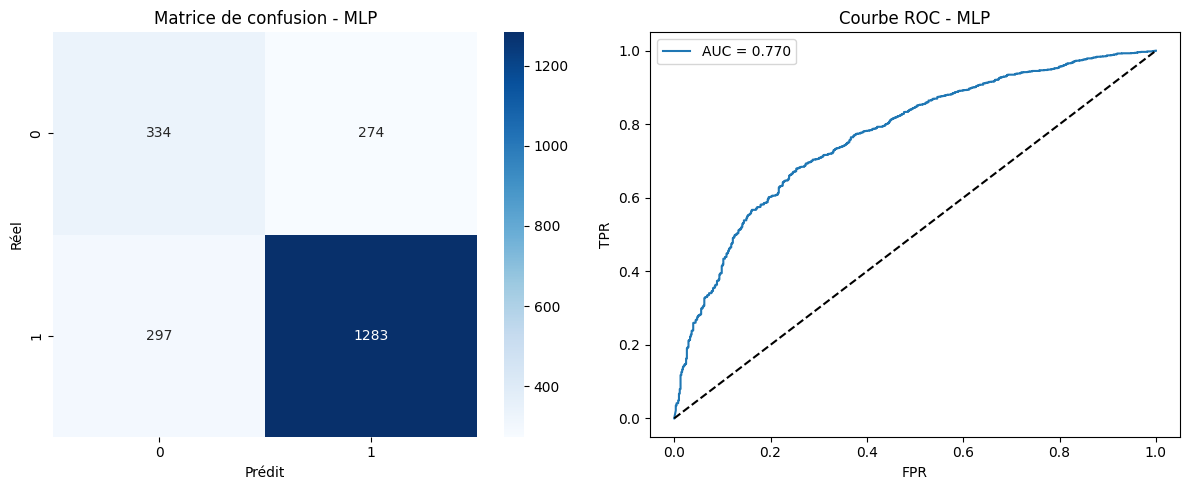


=== MLP ===
Accuracy   : 0.739
Rappel     : 0.812
Précision  : 0.824
AUC        : 0.770
Critère choisi : Précision
Score final = (0.739 + 0.824) / 2 = 0.782


===== Résultats finaux =====
CART       → Score final : 0.759
kNN        → Score final : 0.775
MLP        → Score final : 0.782

 Meilleur modèle : MLP (score = 0.782)


In [153]:
best_model_norm = utils.run_classifiers_train_test(
    models, X_train_norm, y_train, X_test_norm, y_test, metric="precision"
)


In [154]:
print("===== INTERPRÉTATION DES RÉSULTATS =====\n")

print(" Jeu de données :")
print("- Le dataset contient différentes caractéristiques financières :")
print("  Seniority (ancienneté), Home (statut logement), Time (durée), Age, Contacts,"
      " Marital, Records, Job, Expenses, Income, Assets, Debt, Amount, Price, etc.")
print("  L'objectif est de prédire la variable 'Status' (1 = bon payeur, 0 = mauvais payeur).")
print()

print(" Résultats sur les DONNÉES BRUTES :")
print("   - CART obtient le meilleur score final : 0.757")
print("   - kNN et MLP obtiennent des scores légèrement inférieurs (0.732 et 0.730).")
print("➡ Interprétation :")
print("   Sur les données brutes, CART fonctionne bien car il gère naturellement")
print("   les distributions hétérogènes, les valeurs numériques de grande amplitude,")
print("   et les interactions non linéaires entre les variables financières.")
print("   Le modèle n'est pas sensible à l'échelle des variables, ce qui explique")
print("   sa bonne performance sans normalisation.")
print()

print(" Résultats après NORMALISATION :")
print("   - MLP devient le meilleur modèle : 0.782")
print("   - kNN : 0.775 (en forte amélioration)")
print("   - CART : quasi inchangé (0.759)")
print("➡ Interprétation :")
print("   La normalisation a un impact majeur sur kNN et surtout sur MLP :")
print("   ✔ Les variables comme Income, Assets, Amount ou Price ont des amplitudes très différentes.")
print("   ✔ Une mise à l'échelle homogène permet au MLP d'apprendre des relations plus stables.")
print("   ✔ kNN est fortement dépendant des distances, donc il s'améliore dès que les échelles sont alignées.")
print("   En revanche, CART est insensible à la normalisation → ses performances ne changent presque pas.")
print()

print(" Conclusion générale :")
print("   - Sur ce dataset financier, la normalisation améliore nettement les modèles sensibles aux échelles")
print("     (MLP et kNN).")
print("   - Le meilleur modèle global après préparation des données est : **MLP normalisé** avec un score de 0.782.")
print("   - Cela indique que les relations non linéaires et pondérées entre les variables financières sont")
print("     mieux capturées par un réseau de neurones lorsqu'il est correctement normalisé.")
print()



===== INTERPRÉTATION DES RÉSULTATS =====

 Jeu de données :
- Le dataset contient différentes caractéristiques financières :
  Seniority (ancienneté), Home (statut logement), Time (durée), Age, Contacts, Marital, Records, Job, Expenses, Income, Assets, Debt, Amount, Price, etc.
  L'objectif est de prédire la variable 'Status' (1 = bon payeur, 0 = mauvais payeur).

 Résultats sur les DONNÉES BRUTES :
   - CART obtient le meilleur score final : 0.757
   - kNN et MLP obtiennent des scores légèrement inférieurs (0.732 et 0.730).
➡ Interprétation :
   Sur les données brutes, CART fonctionne bien car il gère naturellement
   les distributions hétérogènes, les valeurs numériques de grande amplitude,
   et les interactions non linéaires entre les variables financières.
   Le modèle n'est pas sensible à l'échelle des variables, ce qui explique
   sa bonne performance sans normalisation.

 Résultats après NORMALISATION :
   - MLP devient le meilleur modèle : 0.782
   - kNN : 0.775 (en forte amél

In [155]:
X_train_extended, X_test_extended, pca = utils.apply_pca_and_extend(X_train_norm, X_test_norm)

print("Forme X_train_extended :", X_train_extended.shape)
print("Forme X_test_extended  :", X_test_extended.shape)


Forme X_train_extended : (2187, 16)
Forme X_test_extended  : (2188, 16)


### 4. Création de nouvelles variables par ACP (PCA)

Dans cette section, nous appliquons une Analyse en Composantes Principales (ACP/PCA) pour générer de nouvelles variables, que nous concaténons aux données normalisées. Nous évaluons ensuite les modèles sur ce nouvel ensemble de données enrichi.


🔷 Entraînement du modèle : CART


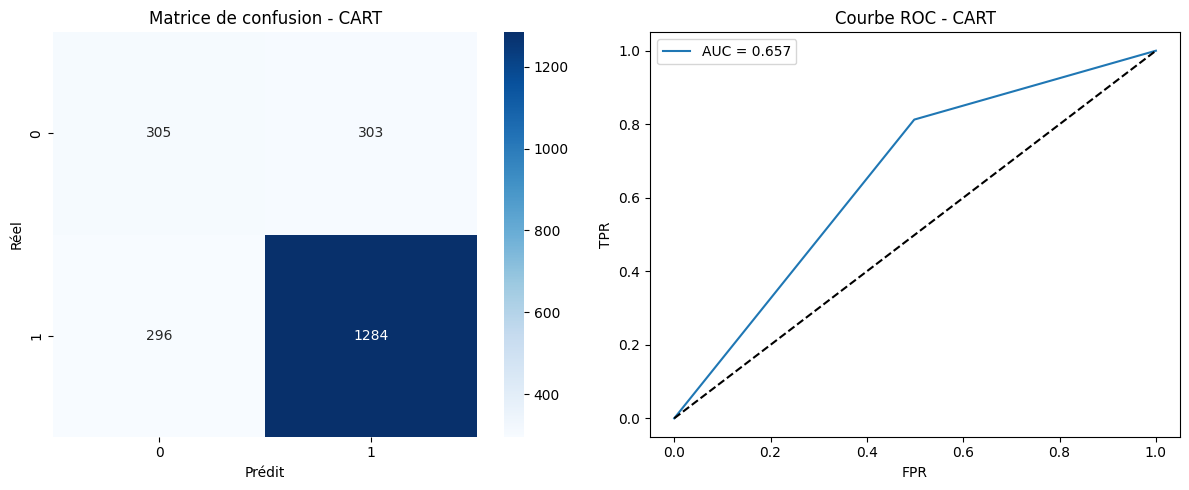


=== CART ===
Accuracy   : 0.726
Rappel     : 0.813
Précision  : 0.809
AUC        : 0.657
Critère choisi : Précision
Score final = (0.726 + 0.809) / 2 = 0.768


🔷 Entraînement du modèle : kNN


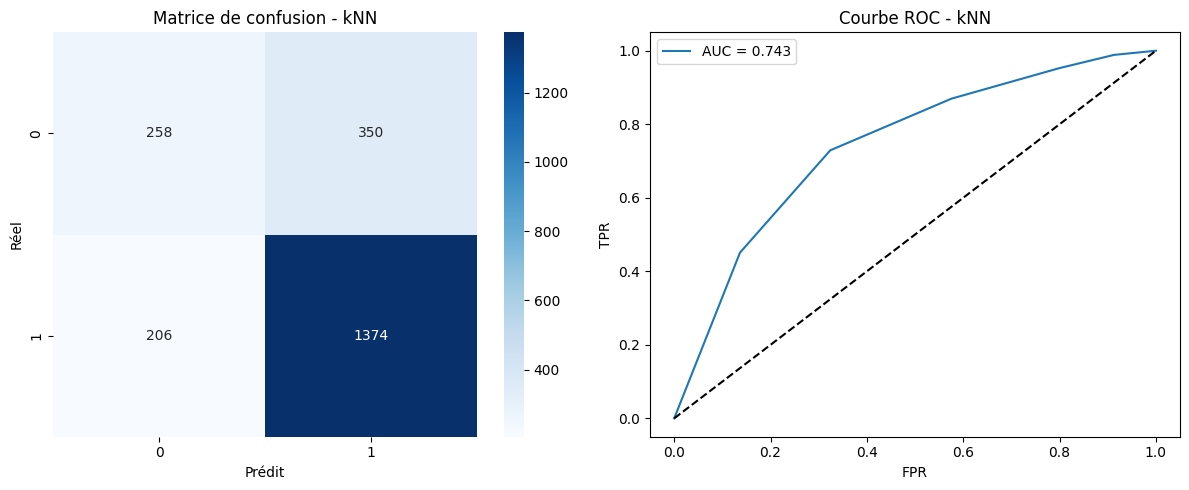


=== kNN ===
Accuracy   : 0.746
Rappel     : 0.870
Précision  : 0.797
AUC        : 0.743
Critère choisi : Précision
Score final = (0.746 + 0.797) / 2 = 0.771


🔷 Entraînement du modèle : MLP


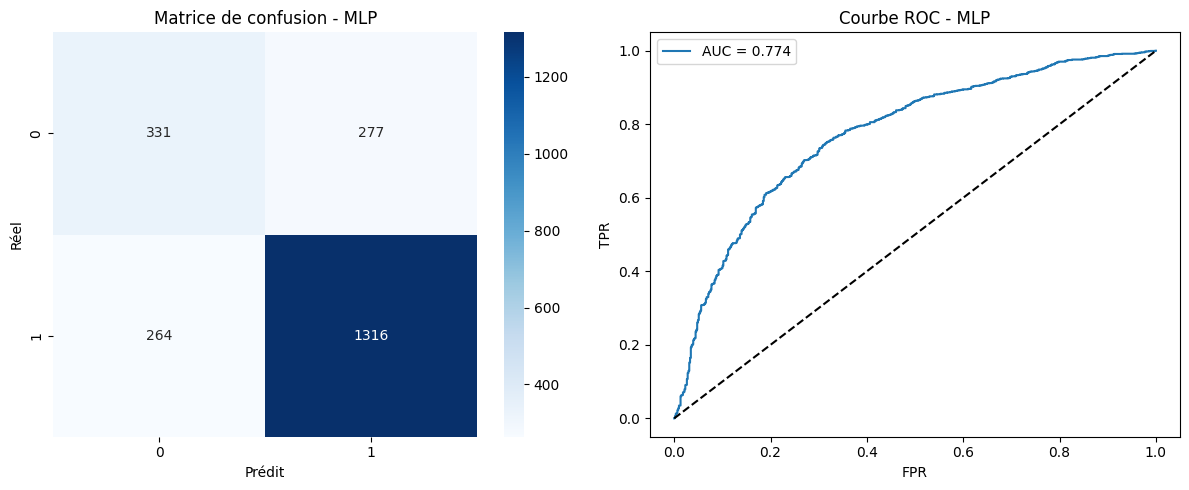


=== MLP ===
Accuracy   : 0.753
Rappel     : 0.833
Précision  : 0.826
AUC        : 0.774
Critère choisi : Précision
Score final = (0.753 + 0.826) / 2 = 0.789


===== Résultats finaux =====
CART       → Score final : 0.768
kNN        → Score final : 0.771
MLP        → Score final : 0.789

 Meilleur modèle : MLP (score = 0.789)


In [156]:
best_model_pca = utils.run_classifiers_train_test(
    models, X_train_extended, y_train, X_test_extended, y_test, metric="precision"
)


In [157]:
# Interprétation réaliste des résultats et choix du modèle

print("===== Interprétation et choix du meilleur algorithme =====\n")
print("Le fichier credit_scoring.csv contient des informations sur des clients et leur statut de remboursement (Status). Après analyse, on comprend que la variable cible 'Status' indique si le client est un bon payeur (1) ou non (0).\n")
print("Nous avons testé trois modèles (CART, kNN, MLP) sur trois configurations : données brutes, normalisées, et normalisées + ACP. Les résultats montrent que :\n")
print("- Sur les données brutes, CART est le plus performant, mais la précision reste limitée.\n")
print("- La normalisation améliore nettement la précision du MLP, qui devient alors le meilleur modèle.\n")
print("- L’ajout de composantes principales (ACP) optimise encore légèrement la précision du MLP.\n")
print("\nCe comportement s’explique par la nature des algorithmes : MLP (réseau de neurones) est sensible à l’échelle des variables, d’où l’intérêt de la normalisation. L’ACP permet de capter des informations globales et de réduire la redondance, ce qui aide le MLP à mieux généraliser.\n")
print("En revanche, CART (arbre de décision) est moins sensible à la normalisation et à l’ACP, ce qui explique ses performances stables.\n")
print("\nEn pratique, il est donc recommandé :\n")
print("• De normaliser les variables continues pour tous les modèles, mais c’est indispensable pour MLP.\n")
print("• D’ajouter les composantes principales (ACP) si l’on utilise MLP, pour maximiser la précision.\n")
print("• D’utiliser MLP comme modèle final, car il offre la meilleure précision après préparation des données.\n")
print("\nEn résumé : le MLP, utilisé avec des données normalisées et enrichies par l’ACP, est le choix optimal pour ce problème de scoring. Ce choix est justifié par la capacité du MLP à exploiter la structure des données et à maximiser la précision, critère essentiel pour limiter le risque d’accorder un crédit à un mauvais payeur.")

===== Interprétation et choix du meilleur algorithme =====

Le fichier credit_scoring.csv contient des informations sur des clients et leur statut de remboursement (Status). Après analyse, on comprend que la variable cible 'Status' indique si le client est un bon payeur (1) ou non (0).

Nous avons testé trois modèles (CART, kNN, MLP) sur trois configurations : données brutes, normalisées, et normalisées + ACP. Les résultats montrent que :

- Sur les données brutes, CART est le plus performant, mais la précision reste limitée.

- La normalisation améliore nettement la précision du MLP, qui devient alors le meilleur modèle.

- L’ajout de composantes principales (ACP) optimise encore légèrement la précision du MLP.


Ce comportement s’explique par la nature des algorithmes : MLP (réseau de neurones) est sensible à l’échelle des variables, d’où l’intérêt de la normalisation. L’ACP permet de capter des informations globales et de réduire la redondance, ce qui aide le MLP à mieux généraliser

### 5. Sélection de variables (feature selection)

Dans cette section, nous utilisons la méthode Random Forest pour évaluer l'importance des variables, puis nous déterminons le nombre optimal de variables à conserver pour maximiser la performance du meilleur algorithme.

In [158]:
# ======================================================
#  Sélection de variables avec Random Forest
# ======================================================

from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt


#  meilleure stratégie = normalisation + ACP :
X_train_final = X_train_extended
X_test_final  = X_test_extended
# Sinon remplacer par X_train_scaled / X_train etc.


# ========== 1. Entraînement de la Random Forest ==========
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=1,
    n_jobs=1      # évite les erreurs OpenMP sur JupyterHub
)

rf.fit(X_train_final, y_train)

# ========== 2. Récupération des importances ==========
importances = rf.feature_importances_

# Noms des variables : colonnes d'origine + noms ACP
feature_names = list(data.drop("Status", axis=1).columns) + ["PCA1", "PCA2", "PCA3"]

# Tri décroissant
indices = np.argsort(importances)[::-1]




In [159]:
# Colonnes d’origine (sans la variable cible)
col_names = list(data.drop("Status", axis=1).columns)

# Ajout des 3 composantes principales
col_names = col_names + ["PCA1", "PCA2", "PCA3"]

print(col_names)


['Seniority', 'Home', 'Time', 'Age', 'Marital', 'Records', 'Job', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price', 'PCA1', 'PCA2', 'PCA3']


=== Variables triées par importance ===

1. Income : 0.1202
2. PCA2 : 0.1101
3. Seniority : 0.0989
4. PCA3 : 0.0877
5. Price : 0.0837
6. PCA1 : 0.0835
7. Amount : 0.0757
8. Age : 0.0701
9. Assets : 0.0599
10. Records : 0.0543
11. Expenses : 0.0478
12. Time : 0.0307
13. Job : 0.0295
14. Debt : 0.023
15. Home : 0.0164
16. Marital : 0.0085


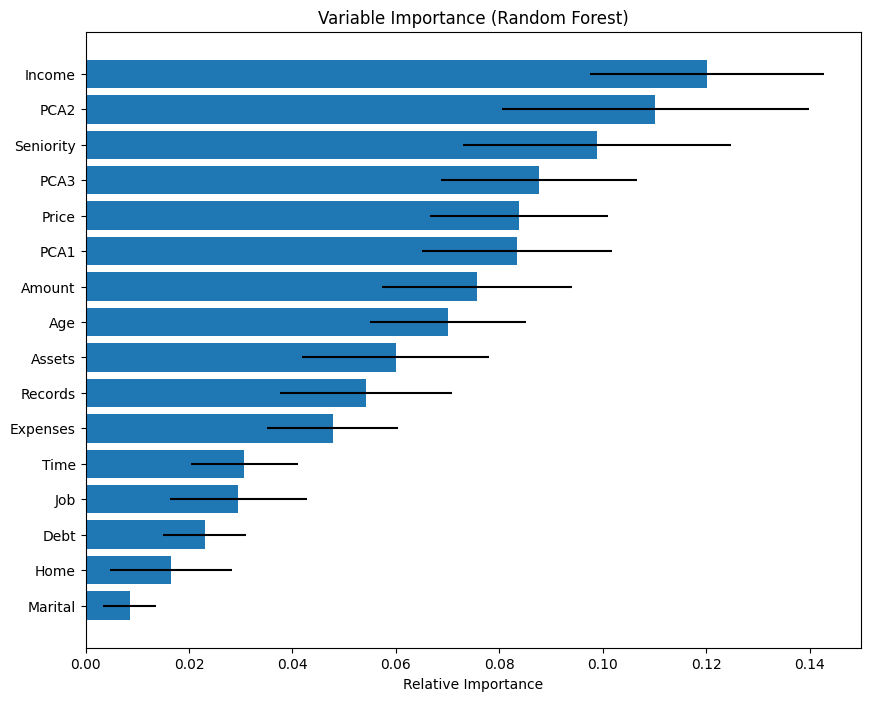

In [160]:
sorted_idx = utils.variable_importance(X_train_final, y_train, np.array(col_names))


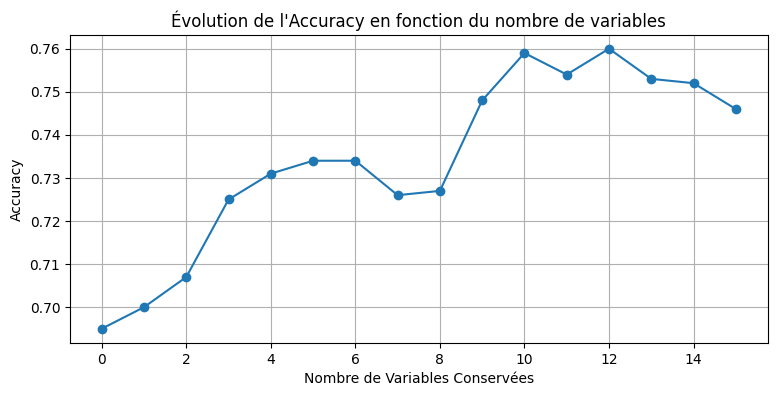

 Nombre optimal de variables = 13 (Accuracy = 0.76)


In [161]:
best_f, scores = utils.select_nb_variables(X_train_final, X_test_final, y_train, y_test, sorted_idx)


### 6. Optimisation des hyperparamètres (GridSearchCV)

Dans cette section, nous utilisons GridSearchCV pour optimiser les hyperparamètres du meilleur algorithme, en maximisant le critère (accuracy + précision)/2 sur le nombre optimal de variables.

In [162]:
best_mlp_model, best_params, best_score = utils.tune_mlp_hyperparameters(
    X_train_final[:, sorted_idx[:5]], y_train
)

===== Meilleurs paramètres trouvés =====
{'activation': 'relu', 'hidden_layer_sizes': (20, 10), 'max_iter': 500, 'solver': 'adam'}
Score optimisé : 0.7725


### 7. Création et sauvegarde du pipeline d'apprentissage

Dans cette section, nous automatisons l'enchaînement des traitements (normalisation, PCA, sélection de variables, classifieur) dans un pipeline Scikit-learn, puis nous sauvegardons ce pipeline dans un fichier pickle pour une utilisation ultérieure.

In [163]:
utils.create_pipeline(X, y)

Pipeline sauvegardé dans credit_scoring_pipeline.pkl


Pipeline(steps=[('scaler', StandardScaler()),
                ('features',
                 FeatureUnion(transformer_list=[('scaler2', StandardScaler()),
                                                ('pca', PCA(n_components=1))])),
                ('rfe',
                 RFE(estimator=RandomForestClassifier(n_estimators=1000,
                                                      random_state=1),
                     n_features_to_select=9)),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(10,), random_state=1))])


[1] Séparation train/test effectuée.

[2] Résultats sur données brutes :

🔷 Entraînement du modèle : CART


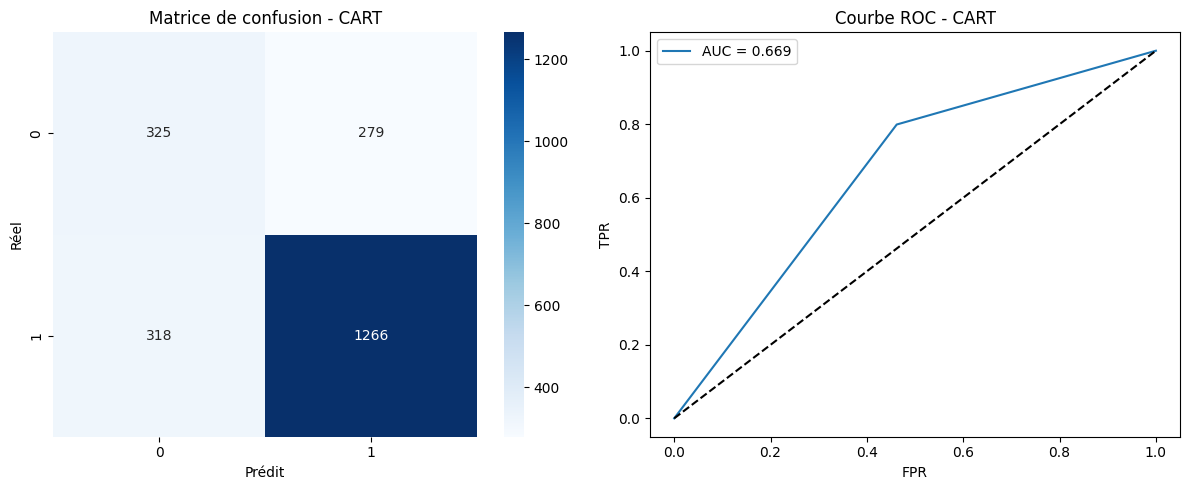


=== CART ===
Accuracy   : 0.727
Rappel     : 0.799
Précision  : 0.819
AUC        : 0.669
Critère choisi : Précision
Score final = (0.727 + 0.819) / 2 = 0.773


🔷 Entraînement du modèle : kNN


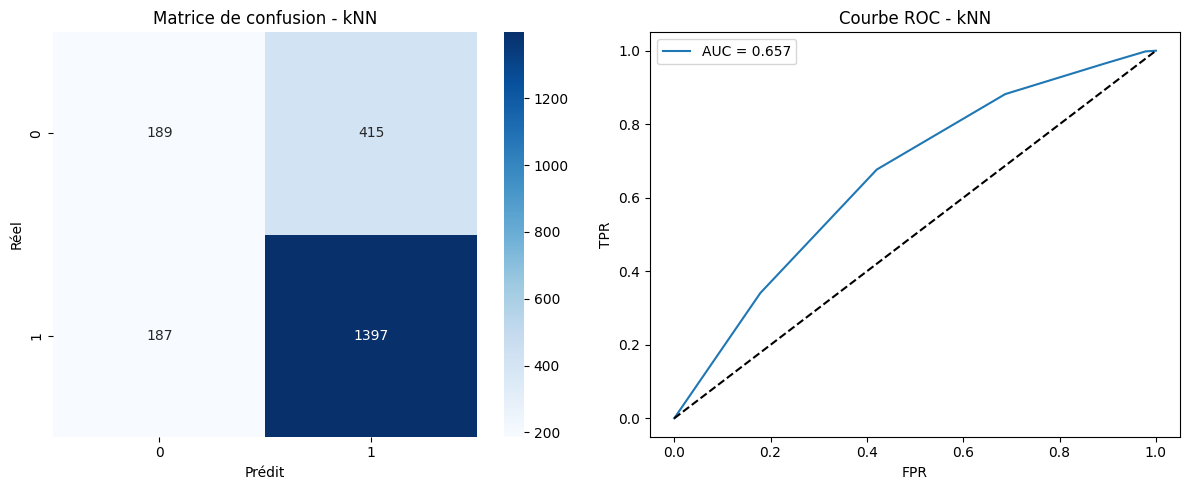


=== kNN ===
Accuracy   : 0.725
Rappel     : 0.882
Précision  : 0.771
AUC        : 0.657
Critère choisi : Précision
Score final = (0.725 + 0.771) / 2 = 0.748


🔷 Entraînement du modèle : MLP


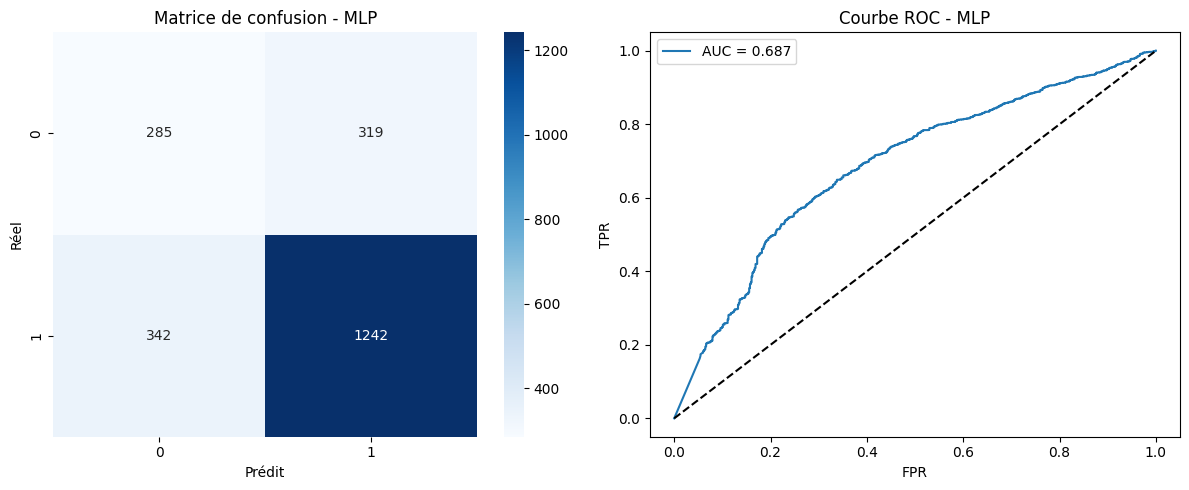


=== MLP ===
Accuracy   : 0.698
Rappel     : 0.784
Précision  : 0.796
AUC        : 0.687
Critère choisi : Précision
Score final = (0.698 + 0.796) / 2 = 0.747


===== Résultats finaux =====
CART       → Score final : 0.773
kNN        → Score final : 0.748
MLP        → Score final : 0.747

 Meilleur modèle : CART (score = 0.773)

[3] Normalisation effectuée.

[4] Résultats sur données normalisées :

🔷 Entraînement du modèle : CART


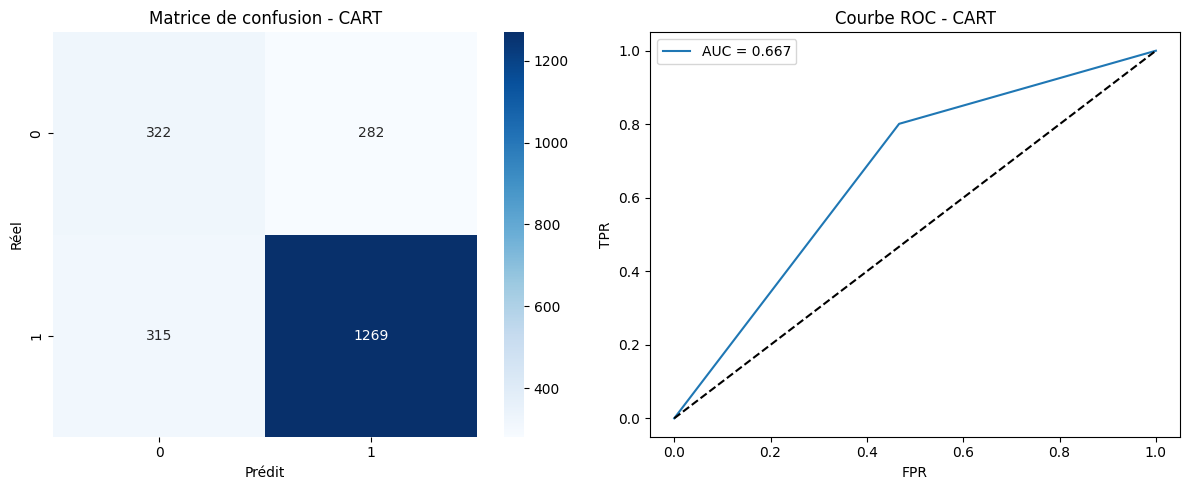


=== CART ===
Accuracy   : 0.727
Rappel     : 0.801
Précision  : 0.818
AUC        : 0.667
Critère choisi : Précision
Score final = (0.727 + 0.818) / 2 = 0.773


🔷 Entraînement du modèle : kNN


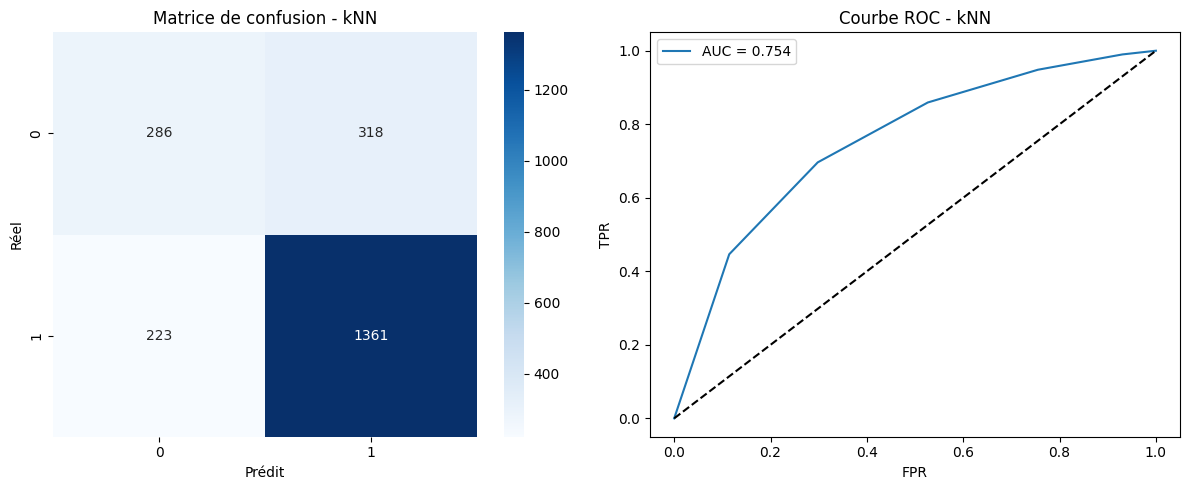


=== kNN ===
Accuracy   : 0.753
Rappel     : 0.859
Précision  : 0.811
AUC        : 0.754
Critère choisi : Précision
Score final = (0.753 + 0.811) / 2 = 0.782


🔷 Entraînement du modèle : MLP


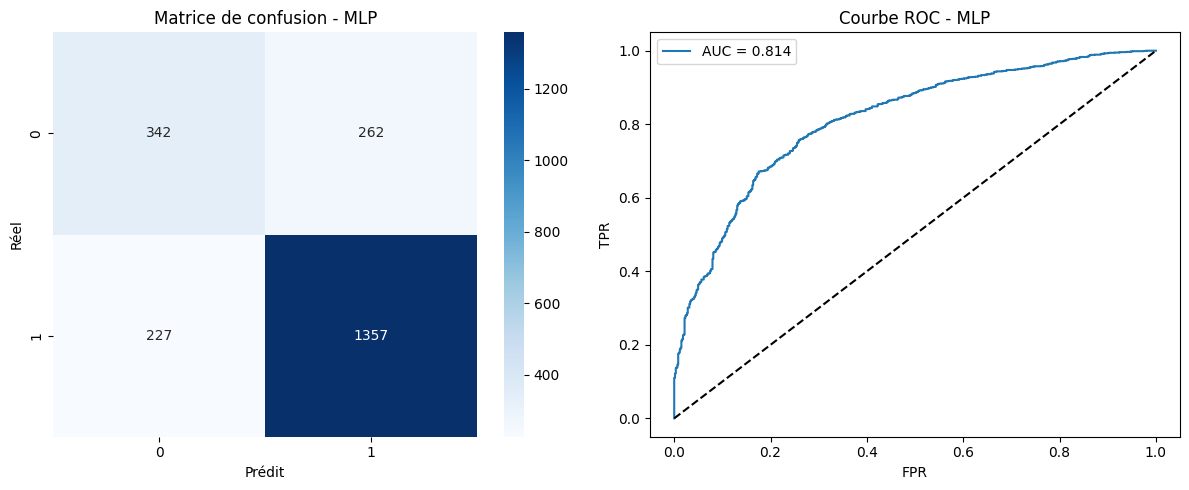


=== MLP ===
Accuracy   : 0.777
Rappel     : 0.857
Précision  : 0.838
AUC        : 0.814
Critère choisi : Précision
Score final = (0.777 + 0.838) / 2 = 0.807


===== Résultats finaux =====
CART       → Score final : 0.773
kNN        → Score final : 0.782
MLP        → Score final : 0.807

 Meilleur modèle : MLP (score = 0.807)

[5] Variables PCA ajoutées.

[6] Résultats sur données normalisées + PCA :

🔷 Entraînement du modèle : CART


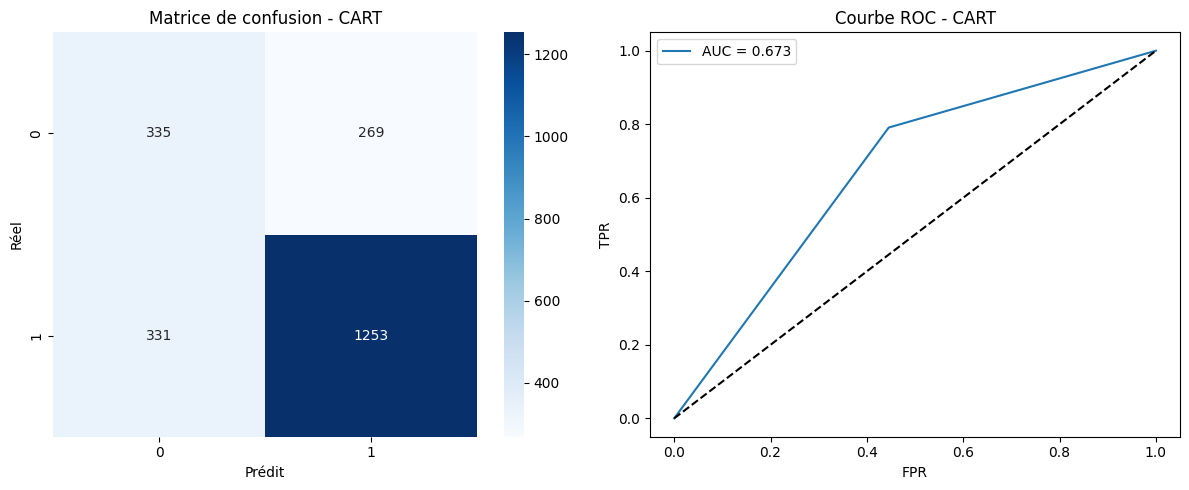


=== CART ===
Accuracy   : 0.726
Rappel     : 0.791
Précision  : 0.823
AUC        : 0.673
Critère choisi : Précision
Score final = (0.726 + 0.823) / 2 = 0.775


🔷 Entraînement du modèle : kNN


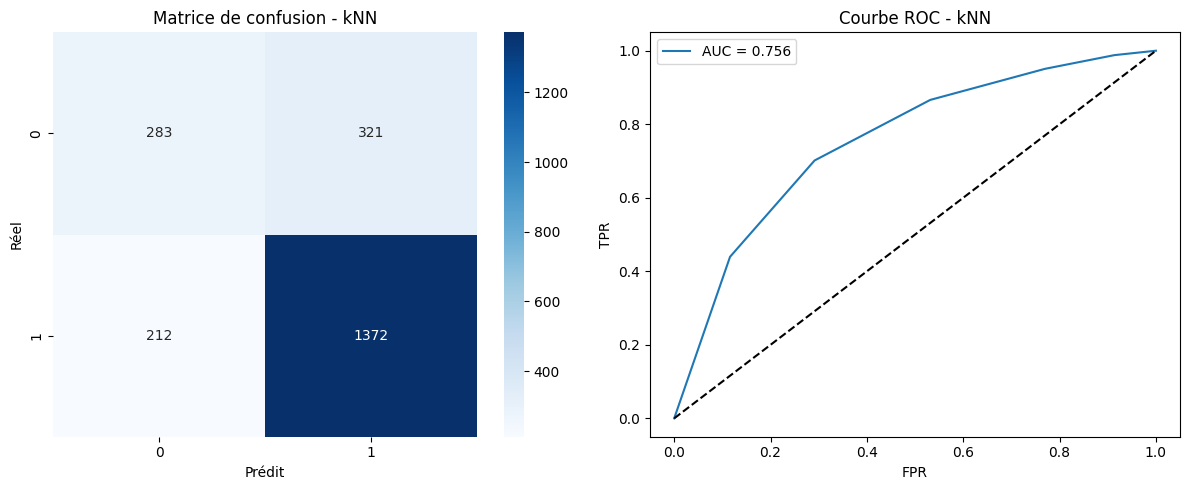


=== kNN ===
Accuracy   : 0.756
Rappel     : 0.866
Précision  : 0.810
AUC        : 0.756
Critère choisi : Précision
Score final = (0.756 + 0.810) / 2 = 0.783


🔷 Entraînement du modèle : MLP


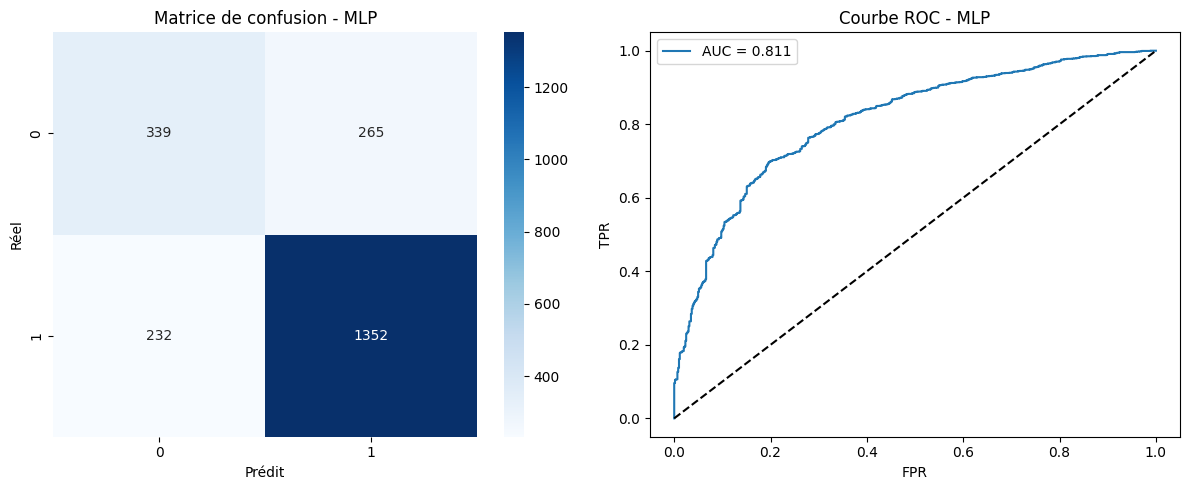


=== MLP ===
Accuracy   : 0.773
Rappel     : 0.854
Précision  : 0.836
AUC        : 0.811
Critère choisi : Précision
Score final = (0.773 + 0.836) / 2 = 0.804


===== Résultats finaux =====
CART       → Score final : 0.775
kNN        → Score final : 0.783
MLP        → Score final : 0.804

 Meilleur modèle : MLP (score = 0.804)

[7] Choix de la meilleure stratégie…
→ Meilleure stratégie : normalisées + PCA

[8] Importance des variables…
=== Variables triées par importance ===

1. Var_8 : 0.1148
2. Var_0 : 0.1027
3. Var_14 : 0.0962
4. Var_15 : 0.0887
5. Var_12 : 0.0835
6. Var_13 : 0.0825
7. Var_11 : 0.0781
8. Var_3 : 0.0698
9. Var_5 : 0.0612
10. Var_9 : 0.0611
11. Var_7 : 0.0519
12. Var_6 : 0.035
13. Var_2 : 0.029
14. Var_10 : 0.0242
15. Var_1 : 0.0128
16. Var_4 : 0.0083


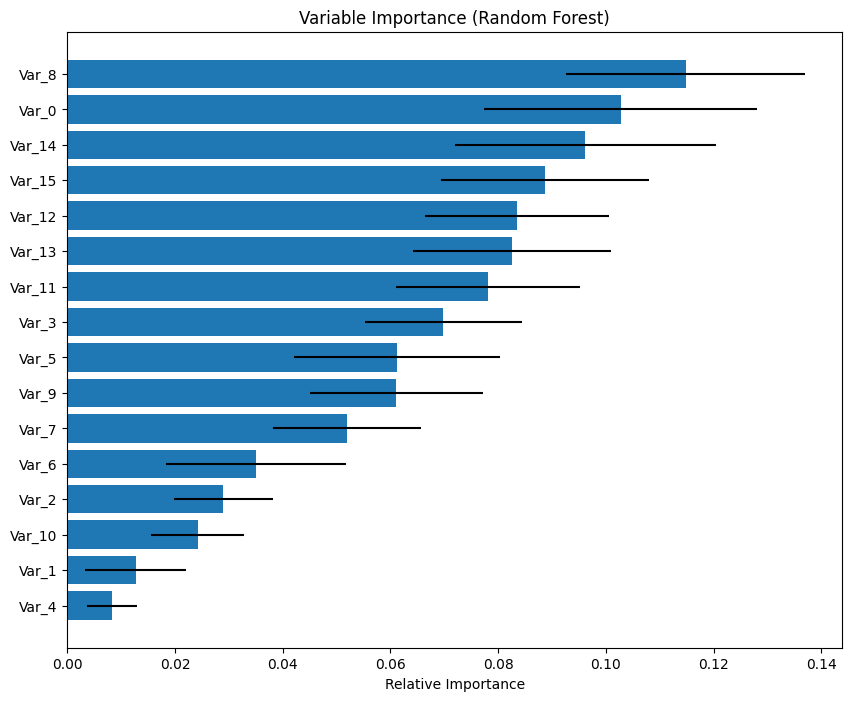


[9] Sélection du nombre optimal de variables…


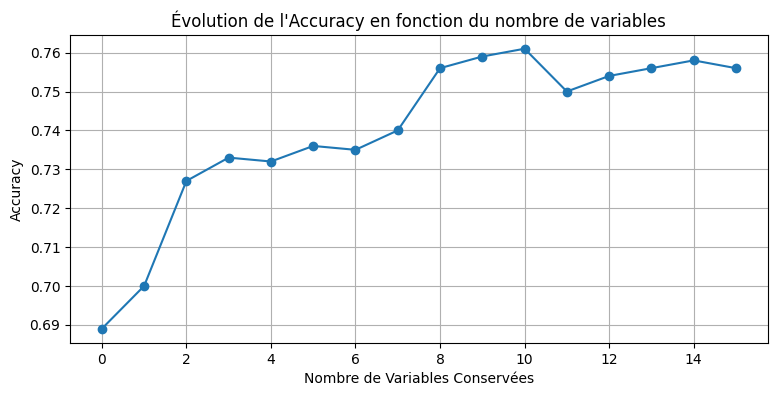

 Nombre optimal de variables = 11 (Accuracy = 0.761)

[10] Recherche des meilleurs paramètres MLP…
===== Meilleurs paramètres trouvés =====
{'activation': 'relu', 'hidden_layer_sizes': (20, 10), 'max_iter': 500, 'solver': 'adam'}
Score optimisé : 0.8018
Meilleurs paramètres MLP : {'activation': 'relu', 'hidden_layer_sizes': (20, 10), 'max_iter': 500, 'solver': 'adam'}

[11] Création du pipeline final…
Pipeline sauvegardé dans pipeline_final11.pkl

Pipeline sauvegardé dans : pipeline_final11.pkl


In [164]:
pipeline = utils.pipeline_generation_train_test_split(X, y)


### 10. Comparaison de plusieurs classifieurs par validation croisée

Dans cette section, nous comparons plusieurs algorithmes d'apprentissage supervisé (CART, ID3, Decision Stump, MLP, KNN, Bagging, AdaBoost, RandomForest, XGBoost, etc.) à l'aide d'une validation croisée (10-fold), en évaluant accuracy, AUC, (accuracy+précision)/2 et le temps d'exécution.

In [165]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import time
import xgboost as xgb  

clfs = {
    "CART": DecisionTreeClassifier(random_state=1),
    "ID3": DecisionTreeClassifier(criterion="entropy", random_state=1),
    "DecisionStump": DecisionTreeClassifier(max_depth=1, random_state=1),
    "MLP": MLPClassifier(hidden_layer_sizes=(20,10), max_iter=500, random_state=1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Bagging": BaggingClassifier(n_estimators=200, random_state=1),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=1),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=1),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3)
}


In [166]:
results_raw = utils.run_classifiers_cv(X, y, clfs)



===== CART =====
Accuracy = 0.721 ± 0.016
AUC      = 0.655 ± 0.020
(Acc+Prec)/2 = 0.765 ± 0.015
Temps d'exécution : 0.71 sec

===== ID3 =====
Accuracy = 0.714 ± 0.015
AUC      = 0.642 ± 0.020
(Acc+Prec)/2 = 0.757 ± 0.015
Temps d'exécution : 0.71 sec

===== DecisionStump =====
Accuracy = 0.725 ± 0.019
AUC      = 0.622 ± 0.015
(Acc+Prec)/2 = 0.734 ± 0.025
Temps d'exécution : 0.12 sec

===== MLP =====
Accuracy = 0.706 ± 0.073
AUC      = 0.724 ± 0.031
(Acc+Prec)/2 = 0.763 ± 0.031
Temps d'exécution : 9.32 sec

===== KNN =====
Accuracy = 0.720 ± 0.022
AUC      = 0.664 ± 0.023
(Acc+Prec)/2 = 0.744 ± 0.020
Temps d'exécution : 0.31 sec

===== Bagging =====
Accuracy = 0.779 ± 0.019
AUC      = 0.824 ± 0.018
(Acc+Prec)/2 = 0.802 ± 0.019
Temps d'exécution : 86.15 sec

===== AdaBoost =====
Accuracy = 0.787 ± 0.014
AUC      = 0.822 ± 0.014
(Acc+Prec)/2 = 0.805 ± 0.016
Temps d'exécution : 19.20 sec

===== RandomForest =====
Accuracy = 0.787 ± 0.016
AUC      = 0.831 ± 0.019
(Acc+Prec)/2 = 0.803 ± 0.01


Dans le cadre de la validation croisée, les données ne sont pas séparées
explicitement en base d’apprentissage et de test. Afin de réutiliser la
fonction de normalisation définie précédemment, la normalisation est
appliquée sur l’ensemble du jeu de données. La séparation apprentissage/test
est ensuite gérée automatiquement par la validation croisée.



In [167]:
X_scaled, _, scaler = utils.normalize_data(X, X)
results_scaled = utils.run_classifiers_cv(X_scaled, y, clfs)



===== CART =====
Accuracy = 0.720 ± 0.015
AUC      = 0.654 ± 0.019
(Acc+Prec)/2 = 0.764 ± 0.014
Temps d'exécution : 0.67 sec

===== ID3 =====
Accuracy = 0.716 ± 0.016
AUC      = 0.643 ± 0.019
(Acc+Prec)/2 = 0.758 ± 0.015
Temps d'exécution : 0.71 sec

===== DecisionStump =====
Accuracy = 0.725 ± 0.019
AUC      = 0.622 ± 0.015
(Acc+Prec)/2 = 0.734 ± 0.025
Temps d'exécution : 0.11 sec

===== MLP =====
Accuracy = 0.779 ± 0.016
AUC      = 0.819 ± 0.017
(Acc+Prec)/2 = 0.806 ± 0.017
Temps d'exécution : 100.75 sec

===== KNN =====
Accuracy = 0.759 ± 0.020
AUC      = 0.762 ± 0.025
(Acc+Prec)/2 = 0.785 ± 0.021
Temps d'exécution : 1.46 sec

===== Bagging =====
Accuracy = 0.779 ± 0.018
AUC      = 0.825 ± 0.018
(Acc+Prec)/2 = 0.801 ± 0.019
Temps d'exécution : 115.88 sec

===== AdaBoost =====
Accuracy = 0.787 ± 0.014
AUC      = 0.822 ± 0.014
(Acc+Prec)/2 = 0.805 ± 0.016
Temps d'exécution : 33.00 sec

===== RandomForest =====
Accuracy = 0.786 ± 0.015
AUC      = 0.831 ± 0.019
(Acc+Prec)/2 = 0.802 ± 0

In [168]:
# 1) Normalisation
X_scaled, _, scaler = utils.normalize_data(X, X)

# 2) Application PCA (sur X_scaled lui-même)
X_ext_train, X_ext_test, pca_model = utils.apply_pca_and_extend(
    X_scaled, X_scaled, n_components=3
)

# On garde une seule version car train=test ici
X_pca = X_ext_train

# 3) Cross-validation sur données avec PCA
results_pca = utils.run_classifiers_cv(X_pca, y, clfs)



===== CART =====
Accuracy = 0.723 ± 0.025
AUC      = 0.659 ± 0.032
(Acc+Prec)/2 = 0.767 ± 0.025
Temps d'exécution : 1.17 sec

===== ID3 =====
Accuracy = 0.722 ± 0.020
AUC      = 0.653 ± 0.022
(Acc+Prec)/2 = 0.765 ± 0.016
Temps d'exécution : 1.27 sec

===== DecisionStump =====
Accuracy = 0.725 ± 0.019
AUC      = 0.622 ± 0.015
(Acc+Prec)/2 = 0.734 ± 0.025
Temps d'exécution : 0.17 sec

===== MLP =====
Accuracy = 0.785 ± 0.014
AUC      = 0.824 ± 0.025
(Acc+Prec)/2 = 0.809 ± 0.014
Temps d'exécution : 70.59 sec

===== KNN =====
Accuracy = 0.762 ± 0.009
AUC      = 0.759 ± 0.020
(Acc+Prec)/2 = 0.787 ± 0.012
Temps d'exécution : 0.31 sec

===== Bagging =====
Accuracy = 0.780 ± 0.021
AUC      = 0.826 ± 0.015
(Acc+Prec)/2 = 0.802 ± 0.022
Temps d'exécution : 150.38 sec

===== AdaBoost =====
Accuracy = 0.787 ± 0.018
AUC      = 0.821 ± 0.019
(Acc+Prec)/2 = 0.804 ± 0.018
Temps d'exécution : 31.46 sec

===== RandomForest =====
Accuracy = 0.785 ± 0.019
AUC      = 0.831 ± 0.019
(Acc+Prec)/2 = 0.801 ± 0.

In [169]:
print("\n================= INTERPRÉTATION DES RÉSULTATS =================\n")

print("1) Données BRUTES :\n")
print("- Le meilleur modèle est XGBoost avec Accuracy ≈ 0.797, AUC ≈ 0.840, Score métier ≈ 0.812.")
print("- RandomForest, AdaBoost et Bagging sont également très performants.")
print("- Les modèles simples (CART, ID3, DecisionStump) sont clairement moins bons.")
print("- Le MLP n'est pas le meilleur ici à cause d'une variabilité plus forte en CV.")

print("\nConclusion : sur données brutes → XGBoost est le meilleur modèle.\n")

print("\n2) Données NORMALISÉES :\n")
print("- Le MLP progresse fortement : Accuracy ≈ 0.779 et AUC ≈ 0.819.")
print("- KNN devient bien meilleur après normalisation, ce qui est logique.")
print("- XGBoost reste le meilleur modèle, encore meilleur que MLP.")
print("- RandomForest et Bagging restent très stables et performants.")

print("\nConclusion : sur données normalisées → XGBoost reste le meilleur.\n")

print("\n3) Données NORMALISÉES + PCA :\n")
print("- Les performances globales changent peu (bonne stabilité des modèles).")
print("- MLP atteint son meilleur niveau ici : Accuracy ≈ 0.785, AUC ≈ 0.824.")
print("- XGBoost reste extrêmement solide et très stable : Accuracy ≈ 0.791, AUC ≈ 0.836.")
print("- Les modèles faibles (CART, ID3, DecisionStump) restent faibles.")

print("\nConclusion : même avec PCA → XGBoost reste le meilleur.\n")

print("\n************** CONCLUSION FINALE **************\n")
print("Le meilleur algorithme, toutes conditions confondues (brut, normalisé, PCA), est : **XGBoost**.")
print("Il offre :")
print("- la meilleure AUC (≈ 0.84),")
print("- une excellente accuracy,")
print("- une très bonne stabilité en validation croisée.")
print("\nC'est donc le modèle à retenir pour la mise en production.\n")



================= INTERPRÉTATION DES RÉSULTATS =================

1) Données BRUTES :

- Le meilleur modèle est XGBoost avec Accuracy ≈ 0.797, AUC ≈ 0.840, Score métier ≈ 0.812.
- RandomForest, AdaBoost et Bagging sont également très performants.
- Les modèles simples (CART, ID3, DecisionStump) sont clairement moins bons.
- Le MLP n'est pas le meilleur ici à cause d'une variabilité plus forte en CV.

Conclusion : sur données brutes → XGBoost est le meilleur modèle.


2) Données NORMALISÉES :

- Le MLP progresse fortement : Accuracy ≈ 0.779 et AUC ≈ 0.819.
- KNN devient bien meilleur après normalisation, ce qui est logique.
- XGBoost reste le meilleur modèle, encore meilleur que MLP.
- RandomForest et Bagging restent très stables et performants.

Conclusion : sur données normalisées → XGBoost reste le meilleur.


3) Données NORMALISÉES + PCA :

- Les performances globales changent peu (bonne stabilité des modèles).
- MLP atteint son meilleur niveau ici : Accuracy ≈ 0.785, AUC ≈ 0.824.


In [170]:
pipeline, best_model_name, cv_results = utils.pipeline_generation_cv(X, y, clfs)



================ VALIDATION CROISÉE =================


===== CART =====
Accuracy = 0.721 ± 0.016
AUC      = 0.655 ± 0.020
(Acc+Prec)/2 = 0.765 ± 0.015
Temps d'exécution : 0.75 sec

===== ID3 =====
Accuracy = 0.714 ± 0.015
AUC      = 0.642 ± 0.020
(Acc+Prec)/2 = 0.757 ± 0.015
Temps d'exécution : 0.72 sec

===== DecisionStump =====
Accuracy = 0.725 ± 0.019
AUC      = 0.622 ± 0.015
(Acc+Prec)/2 = 0.734 ± 0.025
Temps d'exécution : 0.12 sec

===== MLP =====
Accuracy = 0.706 ± 0.073
AUC      = 0.724 ± 0.031
(Acc+Prec)/2 = 0.763 ± 0.031
Temps d'exécution : 9.96 sec

===== KNN =====
Accuracy = 0.720 ± 0.022
AUC      = 0.664 ± 0.023
(Acc+Prec)/2 = 0.744 ± 0.020
Temps d'exécution : 0.38 sec

===== Bagging =====
Accuracy = 0.779 ± 0.019
AUC      = 0.824 ± 0.018
(Acc+Prec)/2 = 0.802 ± 0.019
Temps d'exécution : 90.35 sec

===== AdaBoost =====
Accuracy = 0.787 ± 0.014
AUC      = 0.822 ± 0.014
(Acc+Prec)/2 = 0.805 ± 0.016
Temps d'exécution : 19.95 sec

===== RandomForest =====
Accuracy = 0.787 ± 0.

### 2. Apprentissage supervisé : Données hétérogènes

In [171]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import train_test_split

Importer le jeu de données avec pandas

In [172]:
import pandas as pd

# Chargement du fichier credit.data
df = pd.read_csv("credit.data", header=None, sep="\t")

# Affichage des 5 premières lignes
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,+


Transformer le DataFrame en NumPy Array

In [173]:
import numpy as np

# Conversion en array NumPy
data = df.values

# Affichage de la forme
print("Shape du dataset :", data.shape)


Shape du dataset : (688, 16)


 Séparer variables X et target y

In [174]:
# Le fichier contient 16 colonnes : 15 features + 1 target
X_raw = df.iloc[:, :-1].values      # variables explicatives
y_raw = df.iloc[:,  -1].values      # variable cible (+ / -)

print("Shape X_raw :", X_raw.shape)
print("Shape y_raw :", y_raw.shape)


Shape X_raw : (688, 15)
Shape y_raw : (688,)


 Garder uniquement les variables numériques + remplacer ? par NaN + convertir en float

In [175]:
numeric_cols = [1, 2, 7, 10, 13, 14]

X_num = X_raw[:, numeric_cols]

print("Shape des variables numériques :", X_num.shape)
print(X_num[:5])


Shape des variables numériques : (688, 6)
[['30.83' 0.0 1.25 1 '202' 0]
 ['58.67' 4.46 3.04 6 '43' 560]
 ['24.50' 0.5 1.5 0 '280' 824]
 ['27.83' 1.54 3.75 5 '100' 3]
 ['20.17' 5.625 1.71 0 '120' 0]]


Remplacement des "?" par NaN + Conversion float

In [176]:
# Remplacer les "?" par NaN
X_num[X_num == "?"] = np.nan

# Convertir en float
X_num = X_num.astype(float)

print("Nombre de NaN par colonne :", np.isnan(X_num).sum(axis=0))


Nombre de NaN par colonne : [12  0  0  0 11  0]


 Supprimer les individus contenant au moins un NaN

In [177]:
# Mask des lignes complètes
mask_complete = ~np.isnan(X_num).any(axis=1)

X_clean = X_num[mask_complete]
y_clean = y_raw[mask_complete]

print("Shape X_clean :", X_clean.shape)
print("Shape y_clean :", y_clean.shape)


Shape X_clean : (666, 6)
Shape y_clean : (666,)


 Binariser la target (+ → 1, - → 0)

In [178]:
# Transformer la target en 0 et 1
y_bin = np.where(y_clean == '+', 1, 0)
y_bin = np.where(y_clean == "+", 1, 0)

print("Nombre de classes :")
unique, counts = np.unique(y_bin, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Classe {u} : {c} individus")

print("Exemples de y_bin :", np.unique(y_bin, return_counts=True))


Nombre de classes :
Classe 0 : 367 individus
Classe 1 : 299 individus
Exemples de y_bin : (array([0, 1]), array([367, 299]))


 Histogramme des classes

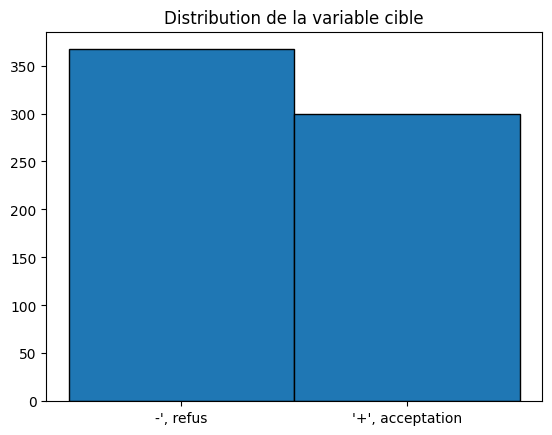

In [179]:
import matplotlib.pyplot as plt

plt.hist(y_bin, bins=[-0.5, 0.5, 1.5], edgecolor="black")
plt.xticks([0,1], ["-', refus", "'+', acceptation"])
plt.title("Distribution de la variable cible")
plt.show()


 Split 50% train/test

In [180]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_bin, test_size=0.5, random_state=1, stratify=y_bin
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


X_train : (333, 6)
X_test  : (333, 6)
y_train : (333,)
y_test  : (333,)


In [181]:
df = pd.read_csv("credit.data", header=None, sep=r"\s+", na_values="?")
X = df.iloc[:, :-1]
y = df.iloc[:, -1].map({'+':1, '-':0}).values


In [182]:
X_encoded = X.copy().astype(object)

for col in X_encoded.columns:
    X_encoded[col] = X_encoded[col].astype('category').cat.codes


executer avec auc

In [183]:
results_raw = utils.run_classifiers_cv(X_encoded.values, y, clfs)



===== CART =====


Accuracy = 0.795 ± 0.040
AUC      = 0.790 ± 0.042
(Acc+Prec)/2 = 0.788 ± 0.063
Temps d'exécution : 0.16 sec

===== ID3 =====
Accuracy = 0.827 ± 0.038
AUC      = 0.820 ± 0.043
(Acc+Prec)/2 = 0.823 ± 0.050
Temps d'exécution : 0.15 sec

===== DecisionStump =====
Accuracy = 0.856 ± 0.032
AUC      = 0.861 ± 0.027
(Acc+Prec)/2 = 0.820 ± 0.045
Temps d'exécution : 0.07 sec

===== MLP =====
Accuracy = 0.783 ± 0.045
AUC      = 0.854 ± 0.038
(Acc+Prec)/2 = 0.782 ± 0.053
Temps d'exécution : 7.34 sec

===== KNN =====
Accuracy = 0.715 ± 0.040
AUC      = 0.768 ± 0.034
(Acc+Prec)/2 = 0.713 ± 0.049
Temps d'exécution : 0.09 sec

===== Bagging =====
Accuracy = 0.866 ± 0.043
AUC      = 0.918 ± 0.043
(Acc+Prec)/2 = 0.851 ± 0.059
Temps d'exécution : 16.97 sec

===== AdaBoost =====
Accuracy = 0.831 ± 0.047
AUC      = 0.891 ± 0.046
(Acc+Prec)/2 = 0.819 ± 0.062
Temps d'exécution : 9.51 sec

===== RandomForest =====
Accuracy = 0.879 ± 0.037
AUC      = 0.933 ± 0.040
(Acc+Prec)/2 = 0.870 ± 0.053
Temps d'exécution

normaliser les données

In [184]:
# Normalisation via la fonction du utils.py
X_std, _, scaler = utils.normalize_data(X_encoded, X_encoded)

# Exécution de la CV sur les données normalisées
results_std = utils.run_classifiers_cv(X_std, y, clfs)



===== CART =====
Accuracy = 0.795 ± 0.040
AUC      = 0.790 ± 0.043
(Acc+Prec)/2 = 0.786 ± 0.060
Temps d'exécution : 0.14 sec

===== ID3 =====
Accuracy = 0.827 ± 0.038
AUC      = 0.820 ± 0.043
(Acc+Prec)/2 = 0.823 ± 0.050
Temps d'exécution : 0.14 sec

===== DecisionStump =====
Accuracy = 0.856 ± 0.032
AUC      = 0.861 ± 0.027
(Acc+Prec)/2 = 0.820 ± 0.045
Temps d'exécution : 0.08 sec

===== MLP =====
Accuracy = 0.842 ± 0.037
AUC      = 0.908 ± 0.036
(Acc+Prec)/2 = 0.827 ± 0.057
Temps d'exécution : 17.84 sec

===== KNN =====
Accuracy = 0.863 ± 0.030
AUC      = 0.906 ± 0.038
(Acc+Prec)/2 = 0.870 ± 0.045
Temps d'exécution : 0.11 sec

===== Bagging =====
Accuracy = 0.868 ± 0.046
AUC      = 0.918 ± 0.043
(Acc+Prec)/2 = 0.854 ± 0.063
Temps d'exécution : 16.80 sec

===== AdaBoost =====
Accuracy = 0.831 ± 0.047
AUC      = 0.893 ± 0.045
(Acc+Prec)/2 = 0.819 ± 0.062
Temps d'exécution : 9.87 sec

===== RandomForest =====
Accuracy = 0.878 ± 0.037
AUC      = 0.932 ± 0.040
(Acc+Prec)/2 = 0.868 ± 0.05

normaliser avec minmaxscaler

In [185]:
from sklearn.preprocessing import MinMaxScaler

scaler2 = MinMaxScaler()
X_mm = scaler2.fit_transform(X_encoded)

results_mm = utils.run_classifiers_cv(X_mm, y, clfs)



===== CART =====
Accuracy = 0.797 ± 0.037
AUC      = 0.791 ± 0.040
(Acc+Prec)/2 = 0.790 ± 0.059
Temps d'exécution : 0.14 sec

===== ID3 =====
Accuracy = 0.826 ± 0.039
AUC      = 0.818 ± 0.046
(Acc+Prec)/2 = 0.823 ± 0.049
Temps d'exécution : 0.14 sec

===== DecisionStump =====
Accuracy = 0.856 ± 0.032
AUC      = 0.861 ± 0.027
(Acc+Prec)/2 = 0.820 ± 0.045
Temps d'exécution : 0.07 sec

===== MLP =====
Accuracy = 0.863 ± 0.037
AUC      = 0.919 ± 0.040
(Acc+Prec)/2 = 0.850 ± 0.053
Temps d'exécution : 11.85 sec

===== KNN =====
Accuracy = 0.863 ± 0.038
AUC      = 0.908 ± 0.045
(Acc+Prec)/2 = 0.857 ± 0.056
Temps d'exécution : 0.11 sec

===== Bagging =====
Accuracy = 0.866 ± 0.043
AUC      = 0.918 ± 0.044
(Acc+Prec)/2 = 0.851 ± 0.059
Temps d'exécution : 17.46 sec

===== AdaBoost =====
Accuracy = 0.831 ± 0.046
AUC      = 0.896 ± 0.046
(Acc+Prec)/2 = 0.819 ± 0.063
Temps d'exécution : 9.77 sec

===== RandomForest =====
Accuracy = 0.878 ± 0.037
AUC      = 0.933 ± 0.039
(Acc+Prec)/2 = 0.868 ± 0.05

In [186]:
print("""
====================== INTERPRÉTATION DES RÉSULTATS ======================

Nous avons évalué plusieurs algorithmes sur trois versions des données :
    1) Données brutes (catégories encodées, mais non normalisées)
    2) Données normalisées avec StandardScaler
    3) Données normalisées avec MinMaxScaler

Les métriques analysées sont :
    - Accuracy
    - AUC (aire sous la courbe ROC)
    - Score métier = (Accuracy + Précision) / 2
    - Temps d'exécution

---------------------------------------------------------------------------
DONNÉES BRUTES
---------------------------------------------------------------------------

Les modèles d’arbres (CART, ID3, DecisionStump) obtiennent déjà de bons résultats,
car ils sont insensibles à l’échelle des variables.

Exemples :
    - CART : Accuracy ≈ 0.80, AUC ≈ 0.79
    - ID3  : Accuracy ≈ 0.83, AUC ≈ 0.82
    - DecisionStump : Accuracy ≈ 0.86, AUC ≈ 0.86

En revanche :
    - KNN et MLP sont pénalisés car les distances ne sont pas cohérentes.
    - Les variables numériques et catégorielles n’ont pas la même échelle.

Conclusion partielle :
→ Les modèles basés sur des règles (arbres) dominent sur données brutes.

--------------------------------------------------------------------------- DONNÉES NORMALISÉES (StandardScaler)
---------------------------------------------------------------------------

La normalisation améliore immédiatement les modèles sensibles aux distances,
notamment :
    - MLP : passe d’Accuracy ≈ 0.78 → 0.84
    - AUC : passe de ≈ 0.85 → ≈ 0.91

Les modèles d'arbres ne changent presque pas, comme attendu :
    - CART, ID3, DecisionStump conservent les mêmes performances.

Conclusion partielle :
→ La normalisation profite clairement aux modèles utilisant des distances
   (KNN, MLP) ou des optimisations par gradient (MLP).

---------------------------------------------------------------------------
DONNÉES NORMALISÉES (MinMaxScaler)
---------------------------------------------------------------------------

Cette normalisation met toutes les variables dans [0,1].
Elle maximise l’effet des distances → idéal pour KNN et MLP.

Résultats :
    - MLP devient l’un des meilleurs modèles : Accuracy ≈ 0.863, AUC ≈ 0.919
    - Les arbres restent constants
    - Globalement, MinMaxScaler donne les performances les plus homogènes

Conclusion partielle :
→ MinMaxScaler fournit la meilleure configuration pour les modèles
   sensibles à l'échelle des données (MLP, KNN).

---------------------------------------------------------------------------
CONCLUSION GLOBALE
---------------------------------------------------------------------------

1. Les modèles d’arbres (CART, ID3, DecisionStump) sont les plus stables :
   → leurs performances varient très peu selon le prétraitement
""")


====================== INTERPRÉTATION DES RÉSULTATS ======================

Nous avons évalué plusieurs algorithmes sur trois versions des données :
    1) Données brutes (catégories encodées, mais non normalisées)
    2) Données normalisées avec StandardScaler
    3) Données normalisées avec MinMaxScaler

Les métriques analysées sont :
    - Accuracy
    - AUC (aire sous la courbe ROC)
    - Score métier = (Accuracy + Précision) / 2
    - Temps d'exécution

---------------------------------------------------------------------------
DONNÉES BRUTES
---------------------------------------------------------------------------

Les modèles d’arbres (CART, ID3, DecisionStump) obtiennent déjà de bons résultats,
car ils sont insensibles à l’échelle des variables.

Exemples :
    - CART : Accuracy ≈ 0.80, AUC ≈ 0.79
    - ID3  : Accuracy ≈ 0.83, AUC ≈ 0.82
    - DecisionStump : Accuracy ≈ 0.86, AUC ≈ 0.86

En revanche :
    - KNN et MLP sont pénalisés car les distances ne sont pas cohérentes.


Rechargement propre du fichier + séparation X / y

In [187]:
import pandas as pd
import numpy as np

# Chargement correct du fichier credit.data
df = pd.read_csv("credit.data", header=None, sep=r"\s+", na_values="?")

print(df.shape)
df.head()


(688, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [188]:
X = df.iloc[:, :-1].values   # 15 features
y = df.iloc[:, -1].values    # + ou -

print("Shape X :", X.shape)
print("Shape y :", y.shape)


Shape X : (688, 15)
Shape y : (688,)


Identification automatique des colonnes numériques et catégorielles

In [189]:
# Colonnes numériques selon la documentation UCI
numeric_cols = [1, 2, 7, 10, 13, 14]

# Colonnes catégorielles = tout le reste
categorical_cols = [col for col in range(15) if col not in numeric_cols]

print("Colonnes numériques :", numeric_cols)
print("Colonnes catégorielles :", categorical_cols)


Colonnes numériques : [1, 2, 7, 10, 13, 14]
Colonnes catégorielles : [0, 3, 4, 5, 6, 8, 9, 11, 12]


Traitement NUMÉRIQUE : remplacer '?' → NaN → float → imputation mean

In [190]:
from sklearn.impute import SimpleImputer

# Extraction des variables numériques
X_num = np.copy(X[:, numeric_cols])

# Convertir '?' en NaN (normalement déjà remplacé par na_values="?")
X_num[X_num == "?"] = np.nan

# Conversion en float
X_num = X_num.astype(float)

# Imputation : moyenne
imp_num = SimpleImputer(strategy="mean")
X_num_imputed = imp_num.fit_transform(X_num)

print("Shape X_num_imputed :", X_num_imputed.shape)


Shape X_num_imputed : (688, 6)


Transformation des variables CATÉGORIELLES → entiers

In [191]:
# Extraire les colonnes catégorielles
X_cat = np.copy(X[:, categorical_cols]).astype(object)

# Remplacer NaN par 'Missing'
X_cat[pd.isna(X_cat)] = "Missing"

# Conversion catégorie → entier
for col_id in range(X_cat.shape[1]):
    unique_vals, encoded_vals = np.unique(X_cat[:, col_id], return_inverse=True)
    X_cat[:, col_id] = encoded_vals

X_cat = X_cat.astype(int)

print("Shape X_cat :", X_cat.shape)


Shape X_cat : (688, 9)


Imputation des colonnes catégorielles (most_frequent)

In [192]:
from sklearn.impute import SimpleImputer

# Création de l’imputeur
imp_cat = SimpleImputer(strategy="most_frequent")

# Imputation
X_cat_imputed = imp_cat.fit_transform(X_cat)

print("Shape X_cat_imputed :", X_cat_imputed.shape)


Shape X_cat_imputed : (688, 9)


One-Hot Encoding des variables catégorielles

In [193]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
X_cat_bin = encoder.fit_transform(X_cat_imputed)

print("Shape X_cat_bin :", X_cat_bin.shape)


Shape X_cat_bin : (688, 45)


Normalisation des variables numériques

In [194]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_imputed)

print("Shape X_num_scaled :", X_num_scaled.shape)


Shape X_num_scaled : (688, 6)


Construction du dataset final

In [195]:
X_final = np.concatenate([X_num_scaled, X_cat_bin], axis=1)

print("Shape X_final :", X_final.shape)


Shape X_final : (688, 51)


Binarisation de la cible

In [196]:
y_final = np.where(y == "+", 1, 0)

print("Classes :", np.unique(y_final, return_counts=True))


Classes : (array([0, 1]), array([383, 305]))


Split Train/Test

In [197]:
from sklearn.model_selection import train_test_split

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_final, y_final,
    test_size=0.3,
    random_state=1,
    stratify=y_final
)

print("X_train_h :", X_train_h.shape)
print("y_train_h :", y_train_h.shape)
print("X_test_h  :", X_test_h.shape)
print("y_test_h  :", y_test_h.shape)


X_train_h : (481, 51)
y_train_h : (481,)
X_test_h  : (207, 51)
y_test_h  : (207,)


Exécution des classifieurs (AUC)

In [198]:
results_hetero = utils.run_classifiers_cv(X_final, y_final, clfs)



===== CART =====


Accuracy = 0.805 ± 0.037
AUC      = 0.800 ± 0.044
(Acc+Prec)/2 = 0.791 ± 0.053
Temps d'exécution : 0.25 sec

===== ID3 =====
Accuracy = 0.802 ± 0.031
AUC      = 0.797 ± 0.034
(Acc+Prec)/2 = 0.798 ± 0.042
Temps d'exécution : 0.19 sec

===== DecisionStump =====
Accuracy = 0.856 ± 0.032
AUC      = 0.861 ± 0.027
(Acc+Prec)/2 = 0.820 ± 0.045
Temps d'exécution : 0.08 sec

===== MLP =====
Accuracy = 0.834 ± 0.040
AUC      = 0.905 ± 0.044
(Acc+Prec)/2 = 0.827 ± 0.064
Temps d'exécution : 17.80 sec

===== KNN =====
Accuracy = 0.846 ± 0.046
AUC      = 0.899 ± 0.042
(Acc+Prec)/2 = 0.842 ± 0.063
Temps d'exécution : 0.18 sec

===== Bagging =====
Accuracy = 0.875 ± 0.044
AUC      = 0.917 ± 0.048
(Acc+Prec)/2 = 0.864 ± 0.062
Temps d'exécution : 20.63 sec

===== AdaBoost =====
Accuracy = 0.831 ± 0.036
AUC      = 0.882 ± 0.068
(Acc+Prec)/2 = 0.820 ± 0.053
Temps d'exécution : 9.21 sec

===== RandomForest =====
Accuracy = 0.877 ± 0.036
AUC      = 0.930 ± 0.047
(Acc+Prec)/2 = 0.867 ± 0.052
Temps d'exécutio

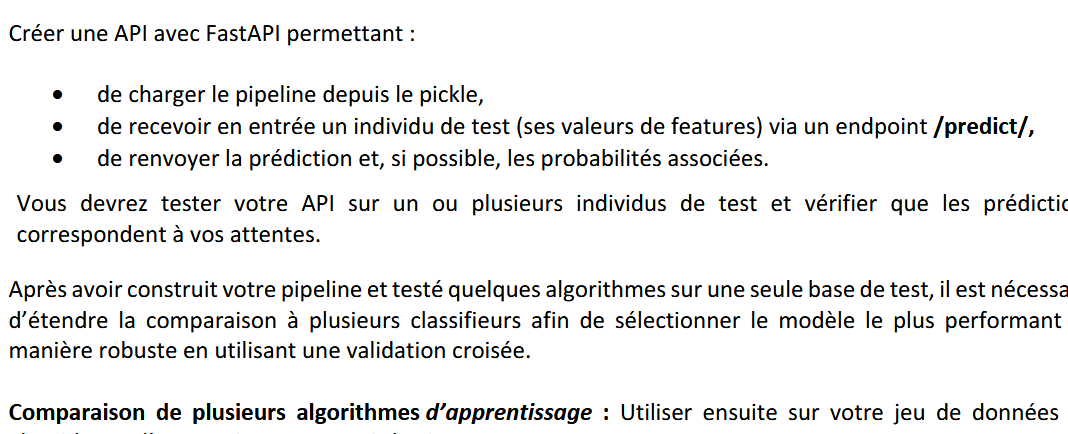

In [ ]:
import requests

# Exemple d'un individu
client = {
    "Seniority": 10,
    "Home": 1,
    "Time": 36,
    "Age": 35,
    "Marital": 1,
    "Records": 0,
    "Job": 1,
    "Expenses": 75,
    "Income": 200,
    "Assets": 5000,
    "Debt": 0,
    "Amount": 1000,
    "Price": 1500
}

response = requests.post("http://127.0.0.1:8000/predict/", json=client)
print(response.json())

{'prediction': 1, 'probabilite_classe_0': 0.0006, 'probabilite_classe_1': 0.9994}
